This notebook explores the foundational theory of Gaussian Processes and provides a practical implementation of the Nearest-Neighbor Gaussian Process approximation. The notebook is structured into two main sections: a theoretical deep dive into standard GP regression, followed by a step-by-step implementation of the highly scalable NNGP approach. A bibliography of the foundational literature is provided at the end.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

**Theory of Gaussian Processes**

Let's imagine we have 100 measurements of temperature in a room between moments 0 and 10. Assume there's a true underlying relationship between time ($\mathbf{x}$) and temperature expressed by $$f(\mathbf{x}) = \sin(\mathbf{x}) + \sin(2\mathbf{x}) * 0.5$$, which we will pretend we don't know. 

To model this unknown continuous curve, we use a Gaussian Process. A Gaussian process is a collection of random variables, any finite number of which have a joint Gaussian distribution. It is completely specified by its mean function and covariance function. We define the mean function $m(\mathbf{x})$ and the covariance function $k(\mathbf{x}, \mathbf{x}')$ of a real process $f(\mathbf{x})$ as:

$$m(\mathbf{x}) = \mathbb{E}[f(\mathbf{x})]$$
$$k(\mathbf{x}, \mathbf{x}') = \mathbb{E}[(f(\mathbf{x}) - m(\mathbf{x}))(f(\mathbf{x}') - m(\mathbf{x}'))]$$

and will write the Gaussian process as:

$$f(\mathbf{x}) \sim \mathcal{GP}(m(\mathbf{x}), k(\mathbf{x}, \mathbf{x}'))$$

*(Usually, for notational simplicity we will take the mean function to be zero, although this need not be done).*

However, in realistic modelling situations like our room, it is typical that we do not have access to the true function values themselves, but only to noisy versions of them. Suppose the thermometer has a reading error of 0.3 degrees, which we also pretend not to know. 

The relationship between our observed targets (the 100 thermometer readings) and the underlying latent function (the true temperature) is expressed by the following observation model:

$$y = f(\mathbf{x}) + \epsilon$$

In this equation:
* $y$ represents our observed, recorded temperatures.
* $f(\mathbf{x})$ represents the true value of the latent function at the input time $\mathbf{x}$.
* $\epsilon$ represents the additive noise component (our thermometer's error). 

This noise is assumed to follow an independent, identically distributed Gaussian distribution with zero mean and a specific variance representing the noise level:

$$\epsilon \sim \mathcal{N}(0, \sigma_n^2)$$

Our goal is to use this framework to estimate the true temperature $f(\mathbf{x})$ at any given time. Since time is a continuous measure, this includes estimating the temperature for the unmeasured moments in between our data points, as well as the times before our first measurement and after our last. Furthermore, the mathematical structure of the Gaussian process allows us to calculate the variance, telling us exactly how much we can trust these predictions.


In [23]:

n_samples = 100 # number of measurements (n)

# let's generate 100 random times between 0 and 10 (our input x)
X_train = np.sort(np.random.uniform(0, 10, n_samples)).reshape(-1, 1)

# the true function that generates the data (the "true" temperature curve), that we want to learn with our model
def true_function(x):
    return np.sin(x) + np.sin(2 * x) * 0.5

# the standard deviation of the noise in the measurements (sigma_n)
noise_std = 0.3  

# create the noisy measurements: y = f(x) + epsilon, which is what we read from the termometer
y_train = true_function(X_train) + np.random.normal(0, noise_std, size=(n_samples, 1))

# let's choose where we want to make predictions (X_test are our x_*)
# we ask the model to predict also outside the data (from -2 to 12)
X_test = np.linspace(-2, 12, 300).reshape(-1, 1)


In our example, we manually set the `length_scale` and `variance` to 1.0. However, in real Machine Learning applications, these values are never guessed. They are learned directly from the data. Looking at the pure theory, the kernel is defined as an expected value: $k(\mathbf{x}, \mathbf{x}') = \mathbb{E}[...]$. However, since we don't know the true function $f(\mathbf{x})$, we cannot calculate this expectation directly. Instead, we choose a kernel to explicitly define the shape of that covariance based on our intuition of the physical problem. We force the model to assume that covariance decays exponentially with distance. It translates our human intuition into math: temperatures measured close together in time will be very similar, while temperatures measured far apart are mostly unrelated. 

For this problem, we use the widely popular Radial Basis Function kernel, and here it has the formula:

$$k(x, x') = \sigma_f^2 \exp\left(-\frac{(x - x')^2}{2l^2}\right)$$

Where:
* $x$ and $x'$ are two different moments in time.
* $l$ is the length-scale: it determines how quickly the correlation drops as points get further apart (a large $l$ means the temperature changes very slowly).
* $\sigma_f^2$ is the variance: it determines the average distance of our function away from its mean.

Similarly, what about the mean function $m(\mathbf{x})$? In our case, because of how we built the function $f(x)$ we know it's 0.

In [24]:
def rbf_kernel(X1, X2, length_scale=1.0, variance=1.0):
    sqdist = np.sum(X1**2, 1).reshape(-1, 1) + np.sum(X2**2, 1) - 2 * np.dot(X1, X2.T)
    return variance * np.exp(-0.5 / length_scale**2 * sqdist)

Now we can compute all these $k(x,x')$ for all the training points and store them in the covariance matrix $K$. From that, we compute the noisy covariance matrix $K_y$ by adding the thermometer's noise variance to the diagonal, which ensures numerical stability:

$$\mathbf{K}_y = \mathbf{K} + \sigma_n^2 \mathbf{I}$$

Now let's introduce these new vector quantities **$\mathbf{k}_*$** and **$\mathbf{y}$** in the context of our thermometer example:

* **$\mathbf{y}$** is the vector of our 100 actual noisy temperatures we recorded.
* **$\mathbf{x}_*$** is our test point, meaning the specific unmeasured moment in time we want to predict (for example, minute 5.5).
* **$\mathbf{k}_*$** is the covariance vector. It is a list of exactly 100 numbers calculated by the kernel. It represents the similarity between our single new test point ($\mathbf{x}_*$) and every single one of our 100 training points. 

With these definitions in mind, the predictive equations represent the core of our model's logic. Specifically:

$$\bar{f}_* = \mathbf{k}_*^\top (K + \sigma_n^2 I)^{-1} \mathbf{y}$$

* **The Predictive Mean ($\bar{f}_*$):** This is our best guess for the temperature at the new time. 

$$\mathbb{V}[f_*] = k(\mathbf{x}_*, \mathbf{x}_*) - \mathbf{k}_*^\top (K + \sigma_n^2 I)^{-1} \mathbf{k}_*$$

* **The Predictive Variance ($\mathbb{V}[f_*]$):** This represents our remaining uncertainty. The closer our test point is to our known data (meaning $\mathbf{k}_*$ contains large similarity values), the larger the subtracted term becomes, shrinking our final uncertainty near zero.

While these equations provide the exact theoretical solution, directly calculating the inverse matrix $(K + \sigma_n^2 I)^{-1}$ is computationally brutal and highly prone to numerical rounding errors. 

To solve this, practical Gaussian Process implementations use the Cholesky decomposition. If we define our noisy covariance matrix as $A = K + \sigma_n^2 I$, the Cholesky algorithm finds a lower triangular matrix $L$ such that:

$$A = L L^\top$$

Here is the mathematical demonstration of why this is incredibly useful for calculating our Predictive Mean and Variance without ever computing $A^{-1}$.

1. The Predictive Mean Proof
Our goal for the mean is to compute: 
$$\bar{f}_* = \mathbf{k}_*^\top A^{-1} \mathbf{y}$$

Instead of directly computing $A^{-1} \mathbf{y}$, we can define a new vector $\boldsymbol{\alpha} = A^{-1} \mathbf{y}$. Multiplying both sides by $A$, this is equivalent to solving the linear system:
$$A \boldsymbol{\alpha} = \mathbf{y}$$

Now, we substitute $A$ with our Cholesky decomposition $L L^\top$:
$$L L^\top \boldsymbol{\alpha} = \mathbf{y}$$

Because $L$ is a triangular matrix, solving this system is extremely fast and stable by forward-backward substitution. We do it in two easy steps:
First, we solve $L \mathbf{v} = \mathbf{y}$ to find the intermediate vector $\mathbf{v}$.
Then, we solve $L^\top \boldsymbol{\alpha} = \mathbf{v}$ to find $\boldsymbol{\alpha}$.

Once the computer finds $\boldsymbol{\alpha}$, our predictive mean formula simply becomes a fast dot product:
$$\bar{f}_* = \mathbf{k}_*^\top \boldsymbol{\alpha}$$

2. The Predictive Variance Proof
Our goal for the variance is to compute the information gain term: $\mathbf{k}_*^\top A^{-1} \mathbf{k}_*$

Using the property of inverses, $(L L^\top)^{-1} = (L^\top)^{-1} L^{-1}$. Let's substitute this into our term:
$$\mathbf{k}_*^\top (L^\top)^{-1} L^{-1} \mathbf{k}_*$$

Notice that $(L^\top)^{-1}$ is the same as $(L^{-1})^\top$. So we can group the terms like this:
$$(\mathbf{k}_*^\top (L^{-1})^\top) (L^{-1} \mathbf{k}_*) \implies (L^{-1} \mathbf{k}_*)^\top (L^{-1} \mathbf{k}_*)$$

Let's define a new vector $\mathbf{v} = L^{-1} \mathbf{k}_*$ (which the computer easily finds by solving the triangular system $L \mathbf{v} = \mathbf{k}_*$). The entire complex term just becomes the dot product of $\mathbf{v}$ with itself ($\mathbf{v}^\top \mathbf{v}$)!

Thus, our predictive variance equation elegantly simplifies to:
$$\mathbb{V}[f_*] = k(\mathbf{x}_*, \mathbf{x}_*) - \mathbf{v}^\top \mathbf{v}$$

By using $L$, we replaced a computationally disastrous matrix inversion with simple, rock-solid triangular linear equations.

In [25]:
# Let's compute the covariance matrix for the training data (K)
K = rbf_kernel(X_train, X_train, length_scale=1.0)

# Add the noise variance to the diagonal (Ky = K + sigma_n^2 * I)
Ky = K + (noise_std**2) * np.eye(n_samples)

#Cholesky decomposition of Ky 
L = np.linalg.cholesky(Ky)

# Compute the covariances between trauning and test points, and between test points themselves
K_star = rbf_kernel(X_train, X_test, length_scale=1.0)
K_star_star = rbf_kernel(X_test, X_test, length_scale=1.0)

# PREDICTION MEAN 
# Using the Cholesky factor L to solve for alpha = (K + noise)^-1 * y
alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))
f_star_bar = K_star.T @ alpha # f_*_bar = k_*.T * (K + noise)^-1 * y

# PREDICTION VARIANCE
# v = L \ k_*
v = np.linalg.solve(L, K_star) 
# V[f_*] = k_** - v.T * v
variance_star = np.diag(K_star_star) - np.sum(v**2, axis=0)
std_star = np.sqrt(variance_star)



Now let's plot!

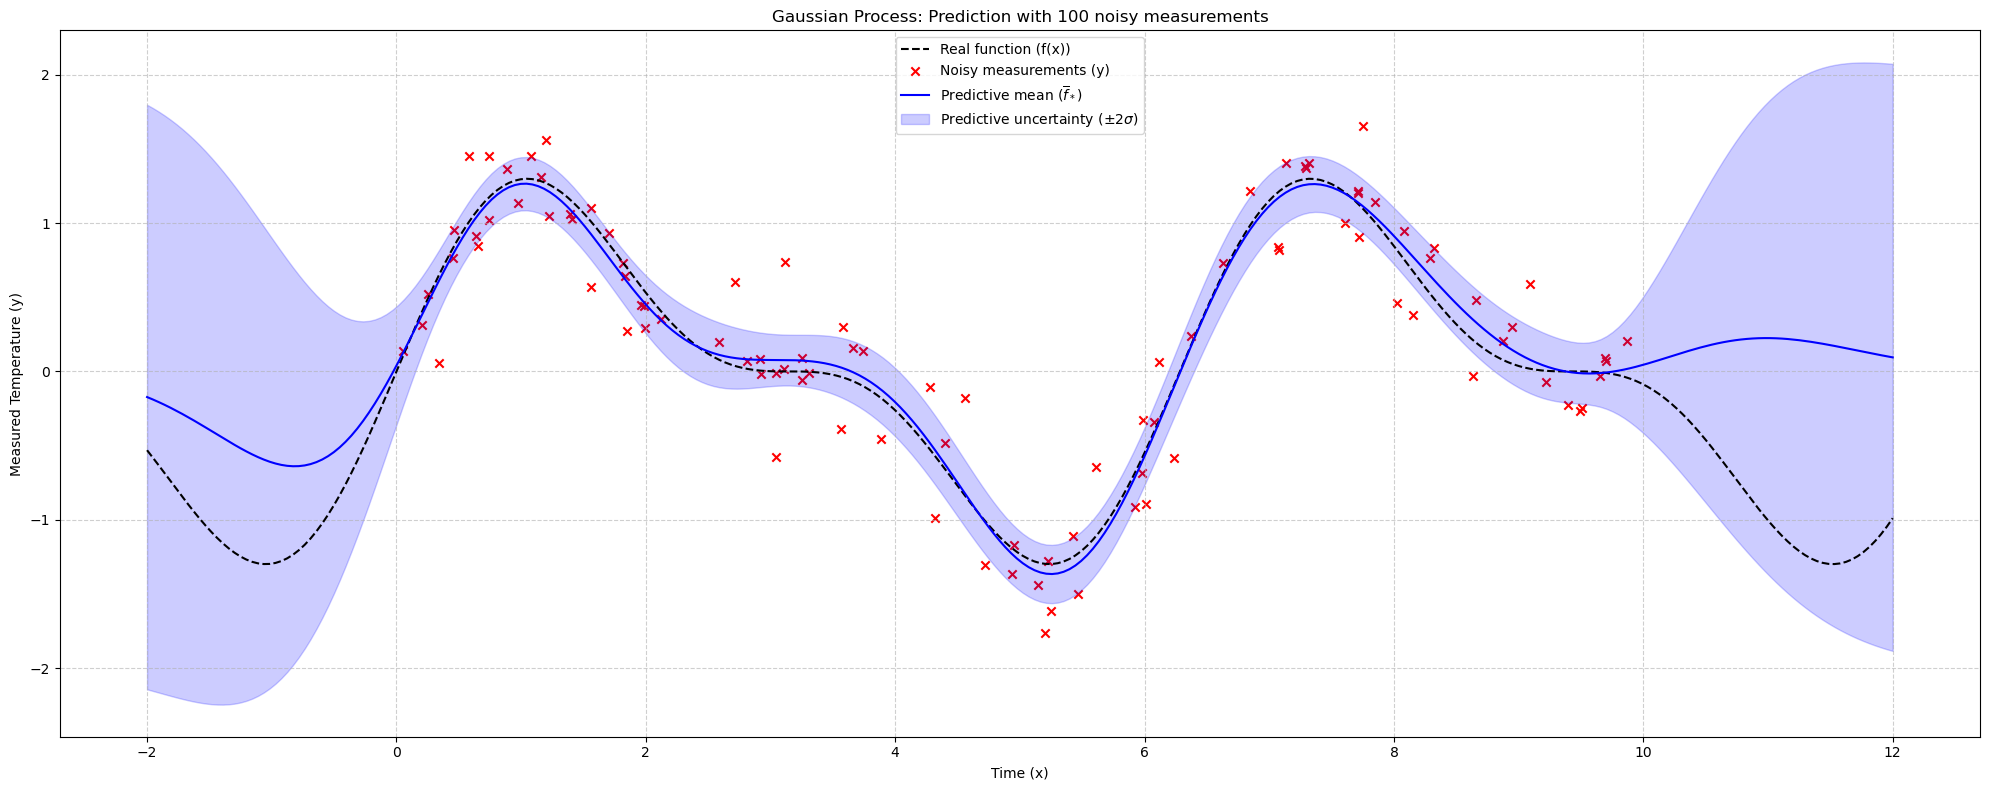

In [27]:
plt.figure(figsize=(20, 8))

# In black the real f(x)
plt.plot(X_test, true_function(X_test), 'k--', label='Real function (f(x))')

# red crosses are the noisy measurements (y) that we have from the termometer
plt.scatter(X_train, y_train, c='red', marker='x', label='Noisy measurements (y)')

# The solid blue line is our model's hypothesis 
plt.plot(X_test, f_star_bar, 'b-', label=r'Predictive mean ($\overline{f}_*$)')

# The blue area is the model's uncertainty 
plt.fill_between(X_test.flatten(), 
                 (f_star_bar.flatten() - 2 * std_star), 
                 (f_star_bar.flatten() + 2 * std_star), 
                 color='blue', alpha=0.2, label=r'Predictive uncertainty ($\pm 2\sigma$)')
                 
plt.title('Gaussian Process: Prediction with 100 noisy measurements')
plt.xlabel('Time (x)')
plt.ylabel('Measured Temperature (y)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

We can see that within the time frame where we collected data, the Gaussian Process seems accurate. Conversely, in the regions outside our data range, the model honestly displays its limitations. The uncertainty band explodes, indicating that the model is no longer confident in its estimates.

In addition, While this approach is good for small datasets, its cubic computational complexity ($\mathcal{O}(n^3)$) makes it unfeasible for massive spatial datasets. To solve this bottleneck, we introduce the Nearest-Neighbor Gaussian Process: by conditioning each location only on a small, localized set of its closest neighbors, we create a sparse precision matrix that drastically reduces the computational cost to a linear scale.

**Nearest Neighbor GP**

To understand exactly how the Nearest-Neighbor Gaussian Process will solve the problem of the computational complexity scaling cubically with the number of points, we first need to represent the process through a sequence of conditional densities and notice a few things.

First, let's use the points we already know. Let's designate our ordered collection of input time points as the reference set $\mathcal{S} = \{\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_k\}$. The true, latent temperature values at these points form the vector $\mathbf{f}_{\mathcal{S}} = (f(\mathbf{x}_1), \dots, f(\mathbf{x}_k))^\top$ .

To find the joint density of all these realizations occurring together, we apply the standard chain rule of probability. The exact joint density $p(\mathbf{f}_{\mathcal{S}})$ is decomposed into a product of conditional densities:

$$p(\mathbf{f}_{\mathcal{S}}) = p(f(\mathbf{x}_1)) p(f(\mathbf{x}_2) | f(\mathbf{x}_1)) \dots p(f(\mathbf{x}_k) | f(\mathbf{x}_{k-1}), \dots, f(\mathbf{x}_1))$$

This formula is the exact mathematical representation of our `for` loop. As we see below in the logs, in this exact formulation, the realization at the current point $f(\mathbf{x}_i)$ strictly depends on the entire history of previously ordered points $\{\mathbf{x}_1, \dots, \mathbf{x}_{i-1}\}$. 

Calculating these conditional probabilities requires continuously inverting the dense history matrix ($K_{history}$), a requirement that quickly becomes computationally prohibitive for large $k$.

In [45]:

f_S = true_function(X_train) 

print(f"--- Calculating density for {n_samples} points ---\n")

for i in range(n_samples):
    if i == 0:
        # Step 1: No history, conditional is just the prior
        cond_mean = 0.0
        cond_var = K[0, 0]
        print(f"Step {i+1} (timestep {X_train[i][0]:.2f}): No history. Variance: {cond_var:.4f}\n")
        
    else:
        # Step i: History consists of all previous points f(x_1), ..., f(x_{i-1})
        history_indices = slice(0, i)
        f_history = f_S[history_indices]
        
        # Submatrices from the full covariance matrix K
        K_history = K[history_indices, history_indices] 
        K_cross = K[i:i+1, history_indices]              # This is our k_*^T
        K_current = K[i, i]                              
        
        # Numerical stability jitter
        K_history += 1e-6 * np.eye(i)
        
        # The computational bottleneck: inverting the history matrix (K^-1)
        K_history_inv = np.linalg.inv(K_history)

        # k_star_K_inv: The weights assigned to the previous points
        k_star_K_inv = K_cross @ K_history_inv
        
        # Conditional mean: (k_*^T K^-1) * f_history
        cond_mean = (k_star_K_inv @ f_history)[0, 0]
        
        # Conditional variance: K_current - (k_*^T K^-1) * k_*
        cond_var = K_current - (k_star_K_inv @ K_cross.T)[0, 0]

        
        if i + 1 in [10, 20, 30, 50, 70, 100]:
            print(f"Step {i+1} (timestep {X_train[i][0]:.2f}):")
            print(f"  -> Dimension history: {i} points.")
            print(f"  -> I'M INVERTING MATRIX: {i}x{i}")
            print(f"  -> Shape of k_*^T K^-1: {k_star_K_inv.shape}")
            print(f"  -> Conditional Variance: {cond_var:.6f}\n")

--- Calculating density for 100 points ---

Step 1 (timestep 0.06): No history. Variance: 1.0017

Step 10 (timestep 0.74):
  -> Dimension history: 9 points.
  -> I'M INVERTING MATRIX: 9x9
  -> Shape of k_*^T K^-1: (1, 9)
  -> Conditional Variance: 0.003287

Step 20 (timestep 1.56):
  -> Dimension history: 19 points.
  -> I'M INVERTING MATRIX: 19x19
  -> Shape of k_*^T K^-1: (1, 19)
  -> Conditional Variance: 0.004077

Step 30 (timestep 2.59):
  -> Dimension history: 29 points.
  -> I'M INVERTING MATRIX: 29x29
  -> Shape of k_*^T K^-1: (1, 29)
  -> Conditional Variance: 0.029714

Step 50 (timestep 4.56):
  -> Dimension history: 49 points.
  -> I'M INVERTING MATRIX: 49x49
  -> Shape of k_*^T K^-1: (1, 49)
  -> Conditional Variance: 0.003789

Step 70 (timestep 6.84):
  -> Dimension history: 69 points.
  -> I'M INVERTING MATRIX: 69x69
  -> Shape of k_*^T K^-1: (1, 69)
  -> Conditional Variance: 0.004019

Step 100 (timestep 9.87):
  -> Dimension history: 99 points.
  -> I'M INVERTING MATRIX

As the loop progresses, we can literally see the computational bottleneck in action. At the first step, there is no matrix to invert, but by step 100, the algorithm is forced to invert a 99 by 99 matrix. If our dataset contained a million points, the computer would eventually try to invert a massive matrix, which would inevitably cause a memory crash.

Furthermore, the model is spending computational resources to calculate the exact influence of the very first temperature reading taken hours ago just to predict the current temperature. In a physical system, these extremely distant past measurements have virtually no real impact on the present state, as we can also intuitively imagine.

Finally, the residual variance values reveal exactly why we can safely approximate this process. At the very first step, the uncertainty is at its maximum. However, by step 10, after observing just nine previous points, the variance drops dramatically to a tiny fraction. By step 100, the uncertainty barely improves any further. Since the model becomes highly confident after seeing just a handful of recent points, it makes perfect mathematical sense to introduce the Nearest-Neighbor Gaussian Process. 

The primary innovation of the Nearest-Neighbor Gaussian Process is the replacement of the massive, prohibitive conditioning sets with smaller, localized neighbor sets, denoted as $N(\mathbf{x}_i)$. 

Instead of looking at the entire history, these sets consist of at most $m$ nearest neighbors (typically $m \approx 10-15$) selected from the points that strictly precede $\mathbf{x}_i$ in our ordering. This substitution transforms the exact joint density into an approximated version, $\tilde{p}(f_{\mathcal{S}})$:

$$\tilde{p}(f_{\mathcal{S}}) = \prod_{i=1}^k p(f(\mathbf{x}_i) | f_{N(\mathbf{x}_i)})$$

By making each point depend only on its immediate neighbors, we form a Directed Acyclic Graph. This structure is mathematically critical: it ensures that the product of these small densities still defines a valid, consistent multivariate joint density. Each localized conditional density follows a normal distribution $\mathcal{N}$:

$$\tilde{p}(f_{\mathcal{S}}) = \prod_{i=1}^k \mathcal{N}(f(\mathbf{x}_i) | \mathbf{B}_{\mathbf{x}_i} f_{N(\mathbf{x}_i)}, \mathbf{F}_{\mathbf{x}_i})$$

The linear coefficients ($\mathbf{B}_{\mathbf{x}_i}$) and the residual variance ($\mathbf{F}_{\mathbf{x}_i}$) are derived directly from the parent kernel $K$, but only using the small neighbor matrices:

* $\mathbf{B}_{\mathbf{x}_i} = \mathbf{K}_{\mathbf{x}_i, N(\mathbf{x}_i)} \mathbf{K}_{N(\mathbf{x}_i)}^{-1}$: These are the weights we previously called $\mathbf{k}_*^\top K^{-1}$, but now the matrix $K$ is only size $m \times m$ instead of $k \times k$.
* $\mathbf{F}_{\mathbf{x}_i} = K(\mathbf{x}_i, \mathbf{x}_i) - \mathbf{B}_{\mathbf{x}_i} \mathbf{K}_{N(\mathbf{x}_i), \mathbf{x}_i}$: This is the conditional variance, representing the uncertainty left after looking at the $m$ neighbors.

Because $m$ is a small constant, the cost of inverting the neighbor matrices is negligible. This reduces the total computational complexity to **$O(km^3)$**, which is linear with respect to the number of observations $k$. 



In [48]:
m = 10  # Number of nearest neighbors (usually 10-15, using 5 for this example)
n_samples = len(X_train)
f_S = true_function(X_train) # Our latent values

print(f"--- NNGP Approximation (m={m}) for {n_samples} points ---\n")

for i in range(n_samples):
    if i == 0:
        # Step 1: No neighbors exist yet
        cond_mean = 0.0
        cond_var = K[0, 0]
        print(f"Step {i+1}: No history. Variance: {cond_var:.4f}\n")
        
    else:
        # Instead of taking ALL previous indices [0:i], 
        # we take only the last 'm' indices.
        start_idx = max(0, i - m)
        neighbor_indices = slice(start_idx, i)
        f_neighbors = f_S[neighbor_indices]
        
        # Current history size (will never exceed m)
        current_m = i - start_idx
        
        K_neighbors = K[neighbor_indices, neighbor_indices] 
        K_x_neighbors = K[i:i+1, neighbor_indices] # This is k_*^T
        K_current = K[i, i]
        
        # Numerical stability jitter
        K_neighbors += 1e-6 * np.eye(current_m)
        
        # THE SOLUTION: We only invert an (m x m) matrix!
        K_neighbors_inv = np.linalg.inv(K_neighbors)
        
        # B_xi (Weights/Linear Coefficients): k_*^T @ K_neighbors^-1
        B_xi = K_x_neighbors @ K_neighbors_inv
        
        # F_xi (Conditional/Residual Variance)
        F_xi = K_current - (B_xi @ K_x_neighbors.T)[0, 0]
        
        # Conditional Mean
        cond_mean = (B_xi @ f_neighbors)[0, 0]
        
        # --- LOGGING THE EFFICIENCY ---
        if i + 1 in [10, 20, 30, 50, 70, 100]:
            print(f"Step {i+1} (timestep {X_train[i][0]:.2f}):")
            print(f"  -> Using only {current_m} nearest neighbors.")
            print(f"  -> I'M INVERTING A SMALL MATRIX: {current_m}x{current_m}")
            print(f"  -> Shape of B_xi (Weights): {B_xi.shape}")
            print(f"  -> F_xi (Uncertainty): {F_xi:.6f}\n")


--- NNGP Approximation (m=10) for 100 points ---

Step 1: No history. Variance: 1.0018

Step 10 (timestep 0.74):
  -> Using only 9 nearest neighbors.
  -> I'M INVERTING A SMALL MATRIX: 9x9
  -> Shape of B_xi (Weights): (1, 9)
  -> F_xi (Uncertainty): 0.003477

Step 20 (timestep 1.56):
  -> Using only 10 nearest neighbors.
  -> I'M INVERTING A SMALL MATRIX: 10x10
  -> Shape of B_xi (Weights): (1, 10)
  -> F_xi (Uncertainty): 0.004611

Step 30 (timestep 2.59):
  -> Using only 10 nearest neighbors.
  -> I'M INVERTING A SMALL MATRIX: 10x10
  -> Shape of B_xi (Weights): (1, 10)
  -> F_xi (Uncertainty): 0.038310

Step 50 (timestep 4.56):
  -> Using only 10 nearest neighbors.
  -> I'M INVERTING A SMALL MATRIX: 10x10
  -> Shape of B_xi (Weights): (1, 10)
  -> F_xi (Uncertainty): 0.004653

Step 70 (timestep 6.84):
  -> Using only 10 nearest neighbors.
  -> I'M INVERTING A SMALL MATRIX: 10x10
  -> Shape of B_xi (Weights): (1, 10)
  -> F_xi (Uncertainty): 0.004879

Step 100 (timestep 9.87):
  -> 

By setting $m=10$, we observe the practical trade-off of the NNGP approximation. Compared to the exact Gaussian Process, the residual uncertainty ($F_{\mathbf{x}_i}$) is slightly higher. This is expected: by ignoring the distant history, we lose a small amount of information. 

However, the computational gain is massive. The matrix inversion size is now capped at 10x10, regardless of how many points we process. 

Unlike many numerical tricks that simply simplify matrices, the Nearest-Neighbor Gaussian Process is a mathematically rigorous spatial process. This means it doesn't just work for the 100 points we chose but it defines a valid probability distribution over the entire, uncountable domain of time or space.

For any new, unmeasured time points $\mathbf{x}_*$, we define their density based exclusively on their nearest neighbors within the reference set $\mathcal{S}$:

$$\tilde{p}(f_{*} | f_{\mathcal{S}}) = \prod_{i=1}^r p(f(\mathbf{x}_{*i}) | f_{N(\mathbf{x}_{*i})})$$

By satisfying the Kolmogorov consistency criteria, NNGP provides a valid, sparsity-inducing prior. This allows it to be embedded directly into large-scale Bayesian frameworks, bypassing the need to ever store or invert large, dense matrices.

In a real-world scenario, we don't just look at the latent temperature $f(t)$; we model the actual observed data $y(t)$ by accounting for other predictors (like elevation or humidity) and measurement noise. The spatially varying regression model is defined as:

$$y(t) = X(t)^\top \beta + f(t) + \epsilon(t)$$

Where:
* **$X(t)^\top \beta$**: Represents fixed effects (predictors and their coefficients).
* **$f(t)$**: Is the spatial/temporal process, which we now assign an NNGP prior.
* **$\epsilon(t)$**: Is the white noise (measurement error) with variance $\sigma_n^2$.

The core mechanism for efficiency is that the joint density over our reference set $\mathcal{S}$ is expressed hierarchically as a product of simple univariate normals:

$$\mathcal{N}(f_{\mathcal{S}}|0, \tilde{K}_{\mathcal{S}}) = \prod_{i=1}^{k} \mathcal{N}(f(\mathbf{x}_{i}) | \mathbf{B}_{\mathbf{x}_{i}} f_{N(\mathbf{x}_{i})}, \mathbf{F}_{\mathbf{x}_{i}})$$

As we saw in our code, the matrices $\mathbf{B}$ and $\mathbf{F}$ are derived locally. Because each component in this product can be evaluated without high-dimensional matrix operations, the model remains incredibly fast.

The computational complexity of fitting this model is drastically lower than a full GP. Given a sample size $n$, a reference set of size $k$, and a neighbor set of size $m$, the total floating-point operations are of the order **$(n+k)m^3$**. 

Since $m$ is a small constant, the complexity is linear in the number of locations. This allows the model to scale to millions of observations where a standard GP would fail.

* Reference Set: For most applications, fixing the reference set to be the set of observed locations is the most effective choice, as it avoids extra sampling steps.
* Neighbor Set Size ($m$): Empirical evidence shows that choosing $m$ between 10 and 15 delivers results almost indistinguishable from the "perfect" full GP. 

This robustness means NNGP can capture complex spatial and temporal signals without the need for large conditioning sets, effectively bypassing the storage and factorization bottlenecks of dense $n \times n$ matrices.

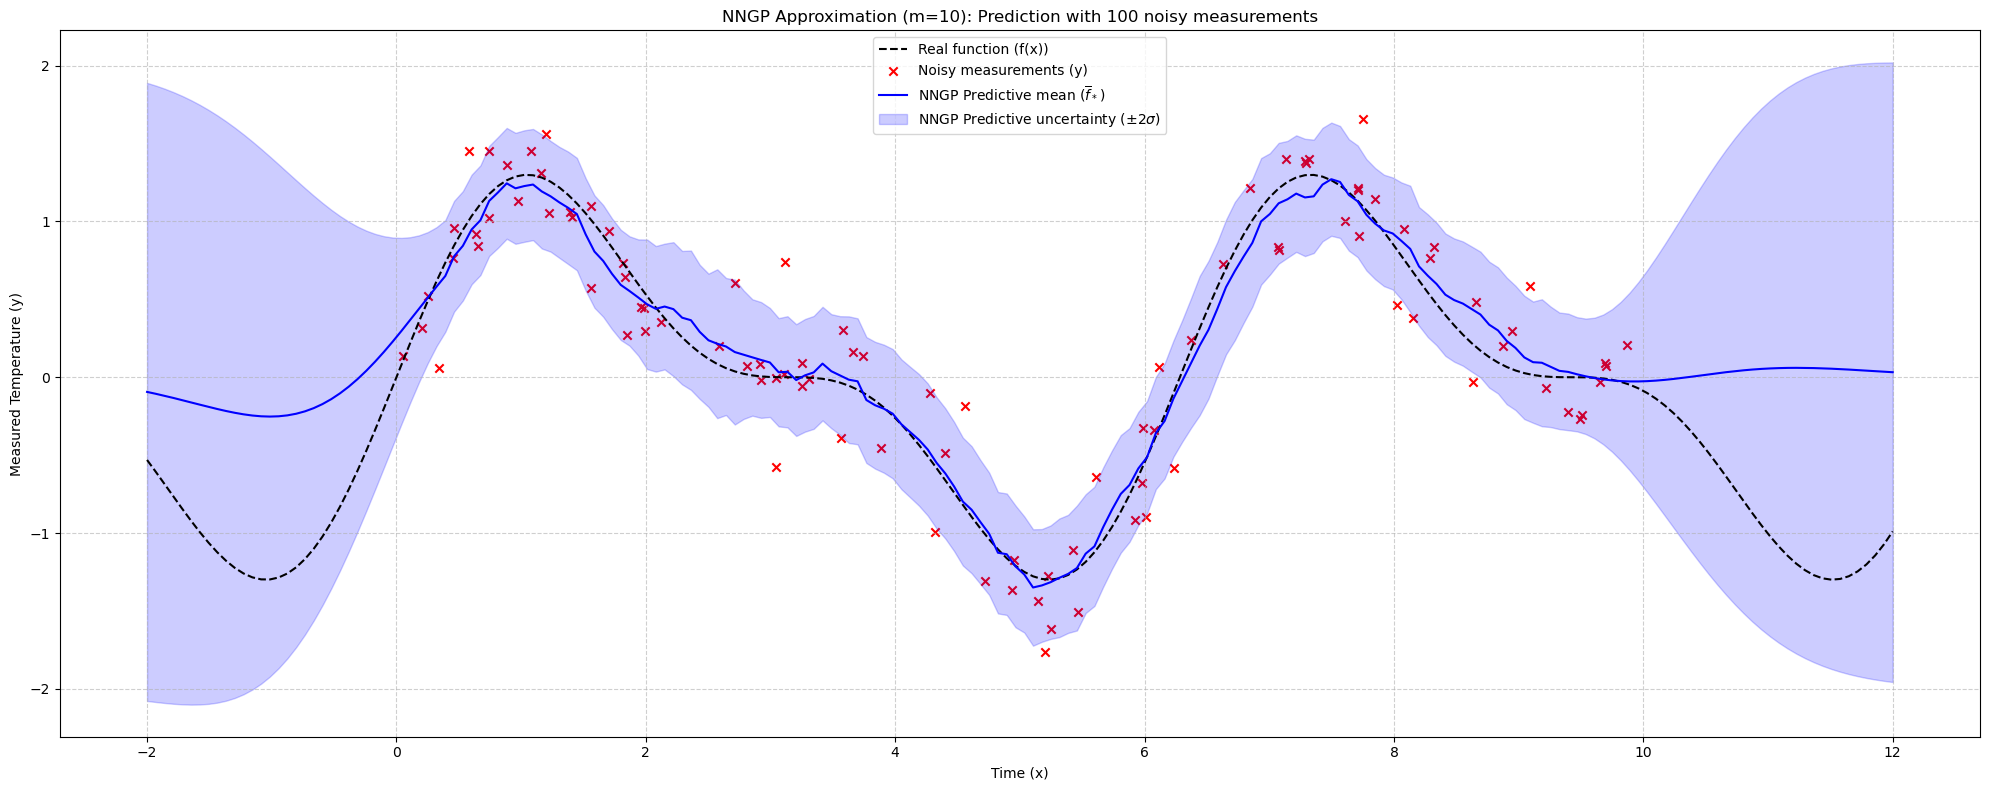

In [58]:

m = 10          
n_test = 200         
X_test = np.linspace(-2, 12, n_test).reshape(-1, 1)

y_S = y_train.flatten() 


sigma_n_sq = 0.3        

def nngp_predict(x_star, X_ref, y_ref, m, length_scale=1.0, sigma_f=1.0, noise=0.0):
    """
    Predice f(x_star) usando SOLO gli m vicini più prossimi nel reference set.
    """

    distances = np.abs(X_ref - x_star).flatten()
    neighbor_indices = np.argsort(distances)[:m]
    
    X_neighbors = X_ref[neighbor_indices]
    y_neighbors = y_ref[neighbor_indices]
    

    K_N = rbf_kernel(X_neighbors, X_neighbors, length_scale, sigma_f) + (noise + 1e-6) * np.eye(m)
    
    k_star = rbf_kernel(x_star.reshape(1,-1), X_neighbors, length_scale, sigma_f)
    
    # B =  (k_*^T K_N^-1)
    B = k_star @ np.linalg.inv(K_N)
    
    # F =  (K_val - B @ k_star^T)
    K_val = sigma_f**2 
    F = K_val - (B @ k_star.T)[0, 0]
    
    mu = (B @ y_neighbors)[0]
    
    return mu, F


mu_nngp = []
var_nngp = []


for x in X_test:

    m_pred, v_pred = nngp_predict(x, X_train, y_S, m, noise=sigma_n_sq)
    mu_nngp.append(m_pred)
    var_nngp.append(v_pred)

mu_nngp = np.array(mu_nngp)
std_nngp = np.sqrt(np.array(var_nngp))


plt.figure(figsize=(20, 8))

# In black the real f(x)
plt.plot(X_test, true_function(X_test), 'k--', label='Real function (f(x))')

# Red crosses are the noisy measurements (y) that we have from the termometer
plt.scatter(X_train, y_S, c='red', marker='x', label='Noisy measurements (y)')

# The solid blue line is our NNGP model's hypothesis 
plt.plot(X_test, mu_nngp, 'b-', label=r'NNGP Predictive mean ($\overline{f}_*$)')

# The blue area is the NNGP model's uncertainty 
plt.fill_between(X_test.flatten(), 
                 mu_nngp - 2 * std_nngp, 
                 mu_nngp + 2 * std_nngp, 
                 color='blue', alpha=0.2, label=r'NNGP Predictive uncertainty ($\pm 2\sigma$)')
                 
plt.title(f'NNGP Approximation (m={m}): Prediction with 100 noisy measurements')
plt.xlabel('Time (x)')
plt.ylabel('Measured Temperature (y)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


While the NNGP successfully recovers the underlying true function, the predictive mean and uncertainty bands appear slightly "jagged" compared to the perfectly smooth full GP. This happens because the model abruptly updates its conditioning set as it moves across the x-axis, relying exclusively on the 10 nearest local neighbors. This minor loss in absolute smoothness is the exact visual trade-off we happily accept to reduce the computational complexity from $O(n^3)$ to a highly scalable $O(n)$.

---

**References**

* **Rasmussen, C. E., & Williams, C. K. I. (2006).** *Gaussian Processes for Machine Learning*. The MIT Press. 
* **Datta, A., Banerjee, S., Finley, A. O., & Gelfand, A. E.** *Hierarchical Nearest-Neighbor Gaussian Process Models for Large Geostatistical Datasets*.

This notebook was authored and developed by Emanuele Elias as a proof-of-concept and exploratory study for the Google Summer of Code 2026. It is specifically targeted towards the PyMC Spatial Modeling project.

* **Project:** PyMC Spatial Modeling (GSoC 2026)
* **Potential Mentors:** Bill Engels & Chris Fonnesbeck